# 02 · the ideas behind the buttons

### CAJAL NEUROMICS summer school, Bordeaux 2026 · a spatial metabolomics primer

*Luca Fusar Bassini · self-guided home prep, notebook 3 of 3 · ~75 minutes*

---

You have a terminal that works (notebook 00) and you can speak enough Python to read and
nudge code (notebook 01). This notebook closes the gap to the real project. From Thursday
onward you will press buttons named `PCA`, `NMF`, `harmony_integrate`, `leiden`,
`mannwhitneyu`. Each button hides one idea. Press a button without the idea and you are
guessing. Hold the idea and you can read every plot, defend every choice, and notice when
something is wrong.

So this notebook is a guided tour of those ideas, in the exact order the pipeline uses them:

> **PCA → NMF → (t-SNE / UMAP) → Harmony → kNN graph + Leiden → kNN label transfer → Wilcoxon + Benjamini-Hochberg**

and then a closing primer on the data itself: **MALDI mass spectrometry imaging and brain lipids**.

We keep the math light. For each method you get four things:

- **the problem** it solves, in one sentence,
- **a picture or analogy** you can hold in your head,
- **where it shows up** in our control-vs-pregnant pipeline,
- **a 2-minute video** by people who explain it better than any paragraph can,

and, wherever it is cheap to do so, **a tiny runnable demo** on a toy table you build below.

The demos matter. Reading "PCA finds directions of variance" teaches you a sentence.
Running PCA on a table you made yourself, and watching the scree plot drop, teaches you
the thing.

## the callouts, again

The same four markers run through every notebook in this course:

- 🔬 **TASK**: something you do (write or run code).
- 💡 **HINT**: a nudge when you are stuck.
- ❓ **QUESTION**: pause and think; no code required.
- ⚠️ **CHECKPOINT**: what you should see if it worked. If your screen disagrees, stop and fix it before moving on.

🔬 **TASK.** Run the next cell to load our libraries. You met all of them in notebook 01.

In [1]:
# the scientific-Python stack you already know, plus the few we add today
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn gives us PCA and NMF with the same fit / transform API
from sklearn.decomposition import PCA, NMF
from sklearn.preprocessing import StandardScaler

# scipy and statsmodels give us the differential test and its multiple-testing fix
from scipy import stats
from statsmodels.stats.multitest import multipletests

# one global seed so every number and figure below is reproducible
RNG_SEED = 0
rng = np.random.default_rng(RNG_SEED)

# a clean, readable plotting style
sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["figure.dpi"] = 110

print("ready. numpy", np.__version__, "| pandas", pd.__version__)

ready. numpy 2.2.6 | pandas 2.3.3


⚠️ **CHECKPOINT.** You should see `ready. numpy ... | pandas ...` and no red error.
If you see a `ModuleNotFoundError`, your notebook is running on the wrong kernel. Go back
to the setup guide and pick the `cajal-lipidomics` kernel (top-right kernel picker).

## the toy table we experiment on

Every demo below runs on one small synthetic dataset, so the ideas stay in focus and nothing
takes more than a second. It is shaped exactly like real MALDI imaging data, just tiny and made up.

Here is the design, and why each piece is there:

- **300 pixels.** A pixel is one laser spot on the tissue. In real data you have tens of thousands;
  300 keeps every plot instant.
- **two spatial regions**, 150 pixels each. Think of one as a **myelin-rich white-matter-like region**
  and the other as a **grey-matter-like region**. Regions differ in their lipid makeup. This is the
  *biology* we want our methods to recover.
- **two conditions**, control and pregnant, split across the regions. Between conditions we inject a
  small, uniform **batch shift** in every lipid, the kind of technical offset that comes from running
  two tissue sections on two different days. This is the *nuisance* we want Harmony to absorb.
- **8 lipid features** (named like real lipids: `PC 34:1`, `SM 18:1;O2/24:1`, ...). Some are myelin
  markers (high in the white-matter region), some are grey-matter markers, some are flat background.
- **all intensities are non-negative**, because a mass-spectrometry peak height is an amount of signal,
  never a negative number. This single fact is why NMF, not just PCA, fits this data so naturally.

🔬 **TASK.** Run the builder. Read the comments as you go; this is the kind of synthetic data you
will see throughout the course.

In [2]:
# ---- ground-truth structure (what the methods should rediscover) ----
n_per_region = 150
n_pixels = 2 * n_per_region

# region label: first half white-matter-like, second half grey-matter-like
region = np.array(["white_matter"] * n_per_region + ["grey_matter"] * n_per_region)

# condition label: interleaved so each region contains both conditions
condition = np.where(np.arange(n_pixels) % 2 == 0, "control", "pregnant")

# the 8 lipid features, named in real lipid nomenclature (decoded later in this notebook)
lipids = ["PC 34:1", "PC 38:6", "PE 38:4", "PS 40:6",
          "SM 18:1;O2/24:1", "HexCer 18:1;O2/24:1", "PI 38:4", "TG 52:2"]

# ---- per-region mean intensity for each lipid (the signal) ----
# rows = the two regions, columns = the 8 lipids; bigger number = more abundant lipid
region_means = np.array([
    # PC34  PC38  PE38  PS40  SM    HexCer PI38  TG
    [ 8.0,  3.0,  4.0,  3.5,  9.0,   8.5,  3.0,  2.0],   # white matter: high sphingolipids (SM, HexCer)
    [ 4.0,  7.5,  7.0,  6.5,  2.5,   2.0,  6.0,  2.2],   # grey matter:  high glycerophospholipids
])
region_idx = (region == "grey_matter").astype(int)   # 0 = white, 1 = grey

# start each pixel from its region's mean, then add non-negative noise
X = region_means[region_idx] + rng.gamma(shape=2.0, scale=0.5, size=(n_pixels, len(lipids)))

# ---- the batch effect: a small uniform lift in pregnant pixels (the nuisance) ----
batch_shift = 1.5
X[condition == "pregnant"] += batch_shift

# ---- one genuine biological difference for the differential test to find ----
# in pregnant pixels, HexCer goes up by a real amount on top of the batch shift
X[condition == "pregnant", lipids.index("HexCer 18:1;O2/24:1")] += 2.5

X = np.clip(X, 0, None)   # intensities can never be negative

# wrap as a tidy pandas table: rows = pixels, columns = lipids + metadata
df = pd.DataFrame(X, columns=lipids)
df["region"] = region
df["condition"] = condition
print(df.shape)
df.head()

(300, 10)


,PC 34:1,PC 38:6,PE 38:4,PS 40:6,SM 18:1;O2/24:1,HexCer 18:1;O2/24:1,PI 38:4,TG 52:2,region,condition
0,8.917155,4.318849,4.533179,5.490271,9.456615,8.992283,3.053205,2.260075,white_matter,control
1,10.029073,5.628280,6.253088,5.473477,12.063142,12.939643,5.071416,3.836753,white_matter,pregnant
2,8.734722,3.979717,4.478528,4.948735,9.256187,10.538959,4.015960,4.173246,white_matter,control
3,12.121150,5.585963,6.330462,5.247670,11.642746,12.778862,5.082169,6.035808,white_matter,pregnant
4,9.064230,5.330311,5.312661,4.367371,10.663893,8.975103,3.865401,2.961041,white_matter,control


⚠️ **CHECKPOINT.** `df.shape` is `(300, 10)`: 300 pixels (rows), 8 lipid columns plus
`region` and `condition`. The first rows are white-matter pixels with high `SM` and `HexCer`,
exactly as we designed.

❓ **QUESTION.** Three things are baked into this table: a *region* difference (biology), a
*condition* batch shift (nuisance), and one *real condition* effect (`HexCer` up in pregnant).
As you read on, keep asking: which method is meant to find which of these?

Before any method, look at the data. A heatmap of mean intensity per region per lipid makes
the structure obvious: the two regions have clearly different lipid fingerprints.

🔬 **TASK.** Run the cell. This is the "plots are the teaching" rule: never analyse a table you
have not first looked at.

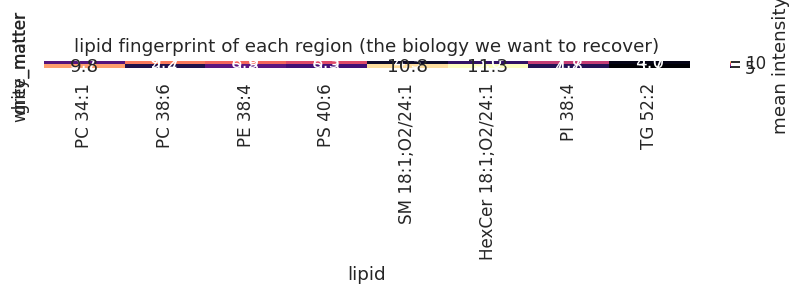

In [3]:
# mean intensity of each lipid within each region -> a small, readable fingerprint
fingerprint = df.groupby("region")[lipids].mean()

fig, ax = plt.subplots(figsize=(8, 2.6))
sns.heatmap(fingerprint, annot=True, fmt=".1f", cmap="magma",
            cbar_kws={"label": "mean intensity"}, ax=ax)
ax.set_title("lipid fingerprint of each region (the biology we want to recover)")
ax.set_xlabel("lipid"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

---
## 1 · PCA: finding the few directions that hold most of the variation

**The problem.** Real lipid data has hundreds of features, and many of them rise and fall together
(correlated). That is redundant and noisy. We want to squeeze the table down to a handful of new
super-features that keep almost all the structure and throw away the noise, *before* we cluster
or visualise.

**The picture.** Imagine the 300 pixels as a cloud of points floating in space, one axis per lipid.
The cloud is not a round ball; it is stretched, like a flattened rugby ball, because the lipids are
correlated. PCA rotates your coordinate axes to line up with the directions the cloud is most
stretched along. The first new axis (**PC1**) points along the longest stretch, capturing the most
variation; PC2 points along the next-longest direction at right angles to PC1; and so on. Keep the
first few axes and you have described almost the whole cloud with a few numbers per pixel.

This connects straight to the linear algebra from notebook 01. PCA is the **eigen-directions of the
covariance matrix**: the new axes are eigenvectors, and each one's eigenvalue is how much variance
sits along it. "Direction the data spreads most" and "top eigenvector of the covariance" are the
same sentence said two ways.

**Where it appears in our pipeline.** PCA is the standard first compression step in single-cell and
spatial omics. In our course we mostly use its non-negative cousin **NMF** (next section) for the
embedding, but PCA is the right thing to understand first, because NMF, t-SNE, UMAP and the whole
neighbour-graph idea all build on "compress first, then look".

📺 **2-minute video.** StatQuest, *PCA main ideas in only 5 minutes*:
<https://www.youtube.com/watch?v=HMOI_lkzW08> (the full step-by-step, 22 min:
<https://www.youtube.com/watch?v=FgakZw6K1QQ>).

🔬 **TASK.** Run PCA on the toy table. The scikit-learn API is the same `fit` / `transform`
pattern you met in notebook 01: build the object, fit it to data, transform data into the new space.

In [4]:
# PCA expects each feature centred (mean 0) and on a comparable scale, so we standardise first.
# StandardScaler subtracts the mean and divides by the standard deviation of each lipid column.
X_lipids = df[lipids].values
X_scaled = StandardScaler().fit_transform(X_lipids)

# fit PCA: ask for all 8 components so we can see how variance is distributed
pca = PCA(n_components=len(lipids), random_state=RNG_SEED)
scores = pca.fit_transform(X_scaled)     # shape (300 pixels, 8 components): each pixel's coords on the new axes

print("explained variance ratio per component:")
print(np.round(pca.explained_variance_ratio_, 3))

explained variance ratio per component:
[0.679 0.212 0.044 0.021 0.018 0.011 0.01  0.005]


The first number is the fraction of all variation captured by PC1 alone. A **scree plot** shows
this for every component; the classic shape is a cliff then a flat scree slope. Where it flattens is
roughly how many components are worth keeping.

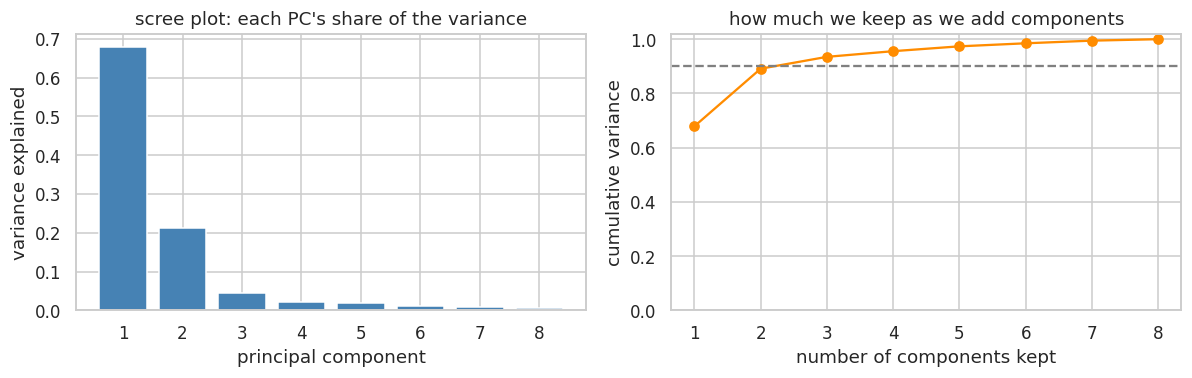

keeping the first 3 components already captures 93% of all variation


In [5]:
# scree plot: variance captured per component, and the running total
evr = pca.explained_variance_ratio_
comps = np.arange(1, len(evr) + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].bar(comps, evr, color="steelblue")
axes[0].set_xlabel("principal component"); axes[0].set_ylabel("variance explained")
axes[0].set_title("scree plot: each PC's share of the variance")

axes[1].plot(comps, np.cumsum(evr), marker="o", color="darkorange")
axes[1].axhline(0.9, ls="--", color="grey")
axes[1].set_xlabel("number of components kept"); axes[1].set_ylabel("cumulative variance")
axes[1].set_title("how much we keep as we add components")
axes[1].set_ylim(0, 1.02)
plt.tight_layout(); plt.show()

n_for_90 = int(np.argmax(np.cumsum(evr) >= 0.90) + 1)
print(f"keeping the first {n_for_90} components already captures "
      f"{np.cumsum(evr)[n_for_90-1]*100:.0f}% of all variation")

⚠️ **CHECKPOINT.** PC1 alone captures a large slice of the variance, the bars drop fast, and
the dashed line tells you only a few components are needed for ~90%. That is the whole point: 8
correlated lipids really live in a 2. 3 dimensional shape.

Now plot the pixels in the PC1. PC2 plane, coloured by their true region. If PCA worked, the two
regions should separate along the first axis even though PCA never saw the region labels.

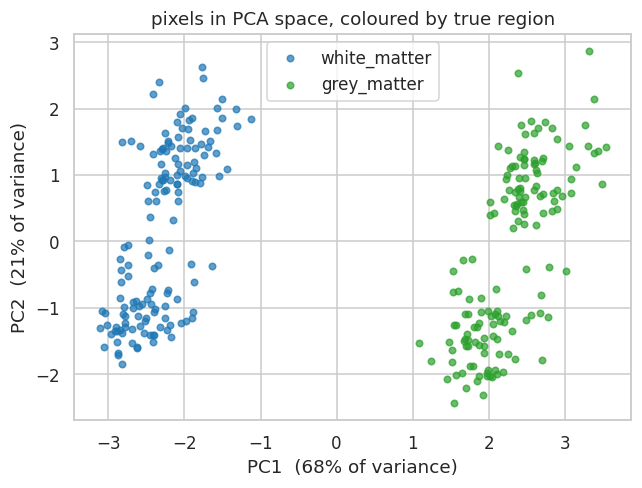

In [6]:
# PCA is unsupervised: it never saw the labels. We colour AFTER the fact to check what it found.
fig, ax = plt.subplots(figsize=(6, 4.6))
for reg, colour in [("white_matter", "tab:blue"), ("grey_matter", "tab:green")]:
    m = df["region"].values == reg
    ax.scatter(scores[m, 0], scores[m, 1], s=18, alpha=0.7, label=reg, color=colour)
ax.set_xlabel(f"PC1  ({evr[0]*100:.0f}% of variance)")
ax.set_ylabel(f"PC2  ({evr[1]*100:.0f}% of variance)")
ax.set_title("pixels in PCA space, coloured by true region")
ax.legend(); plt.tight_layout(); plt.show()

❓ **QUESTION.** The two regions split cleanly along PC1, which PCA chose purely from the
numbers. What does that tell you about which signal in the data is the *strongest*? (Hint: the
biggest source of variation in the table is the region difference. PCA always grabs the biggest
source first, whether that source is biology or, as we will see with Harmony, a batch effect.)

---
## 2 · NMF: PCA's cousin that gives positive, additive parts

**The problem.** PCA's axes are mathematically tidy but hard to read biologically: a principal
component can mix lipids with plus and minus signs, so it says things like "more `PC` *minus* `SM`".
A negative amount of a lipid is meaningless. We want components that read like real biology:
**lipid programs** that are present in some amount and add up. That is NMF.

**The picture.** NMF takes your non-negative pixel-by-lipid matrix **V** and factors it into two
smaller non-negative matrices, **V ≈ W · H**:

- **H** holds a few **lipid programs** (also called factors or components). Each program is a recipe:
  a non-negative weight for every lipid. One program might be "lots of `SM` and `HexCer`", the myelin
  recipe; another "lots of `PC`, `PE`, `PS`", the grey-matter membrane recipe.
- **W** says **how much of each program each pixel expresses**, again all non-negative.

Because nothing is ever subtracted, every pixel is literally a *sum of programs, each present in some
non-negative amount*. This is the classic "parts that add up" intuition: the famous result that NMF on
face images discovers parts like noses and eyebrows, while PCA discovers ghostly whole-face
"eigenfaces" with positive and negative pixels. Same factorisation idea, but non-negativity forces
the parts to be things you can point at.

**Why non-negativity gives interpretable lipid programs.** Lipid intensities are non-negative by
physics (a peak height is an amount). Constrain the factors to be non-negative too and the model can
only *build pixels up from ingredients*, never cancel one lipid against another. The resulting
programs line up with biology you can name. That is exactly why this course embeds with NMF rather
than PCA: **the NMF factors are the representation the pipeline actually clusters on**, and we want
those factors to mean something.

**Where it appears in our pipeline.** Notebook N4 learns a seeded NMF embedding on the control section
and applies it to both sections. Every later step, neighbours, Leiden clustering, label transfer,
runs on these NMF factors. So this is worth real attention.

📺 **2-minute idea.** There is no single canonical short NMF video; the cleanest written intuition is
*The why and how of nonnegative matrix factorization*:
<https://blog.acolyer.org/2019/02/18/the-why-and-how-of-nonnegative-matrix-factorization/>. The
scikit-learn reference (the exact function we call) is here:
<https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.NMF.html>. For the original
"parts of objects" result, see Lee & Seung 1999: <https://www.nature.com/articles/44565>.

🔬 **TASK.** Run NMF asking for **2 programs** (we built the data with two regions, so two
recipes should suffice). Note we feed the *raw non-negative* intensities, not the standardised values,
because NMF needs non-negative input.

In [7]:
# NMF needs non-negative input -> feed the raw intensities, not the standardised matrix
k = 2  # number of lipid programs to look for
nmf = NMF(n_components=k, init="nndsvda", random_state=RNG_SEED, max_iter=1000)
W = nmf.fit_transform(X_lipids)   # (300 pixels, 2 programs): how much of each program per pixel
H = nmf.components_               # (2 programs, 8 lipids):   the recipe of each program

print("V (data)   shape:", X_lipids.shape)
print("W (pixels x programs):", W.shape)
print("H (programs x lipids):", H.shape)
print("\nall of W and H are non-negative:", (W >= 0).all() and (H >= 0).all())

V (data)   shape: (300, 8)
W (pixels x programs): (300, 2)
H (programs x lipids): (2, 8)

all of W and H are non-negative: True


Look at **H**, the recipes. Each row is one program; the bars show how much each lipid
contributes. We expect one program dominated by the sphingolipids (`SM`, `HexCer`) and one by the
glycerophospholipids (`PC`, `PE`, `PS`, `PI`).

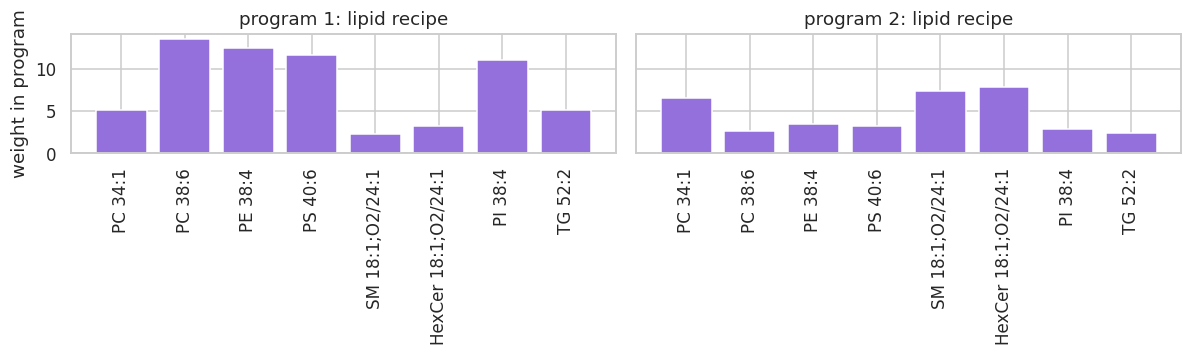

In [8]:
# H: the two lipid programs as bar charts (the recipes)
fig, axes = plt.subplots(1, k, figsize=(11, 3.4), sharey=True)
for j in range(k):
    axes[j].bar(lipids, H[j], color="mediumpurple")
    axes[j].set_title(f"program {j+1}: lipid recipe")
    axes[j].tick_params(axis="x", rotation=90)
axes[0].set_ylabel("weight in program")
plt.tight_layout(); plt.show()

Now look at **W**, how much of each program each pixel uses, coloured by true region. A pixel
in the myelin-like region should lean on the sphingolipid program; a grey-matter pixel on the other.

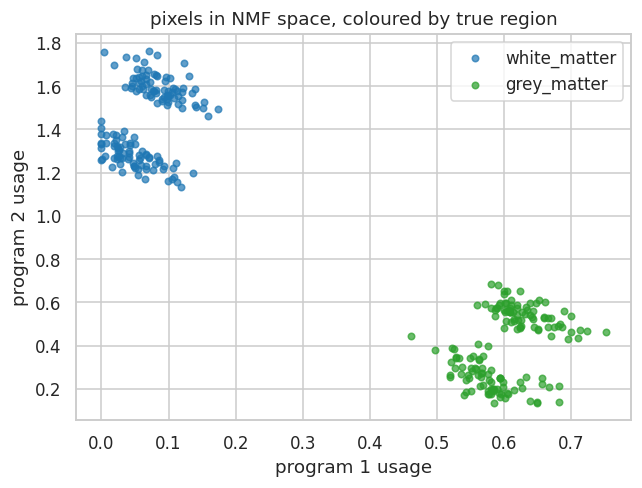

In [9]:
# W: each pixel placed by how much of program 1 vs program 2 it expresses
fig, ax = plt.subplots(figsize=(6, 4.6))
for reg, colour in [("white_matter", "tab:blue"), ("grey_matter", "tab:green")]:
    m = df["region"].values == reg
    ax.scatter(W[m, 0], W[m, 1], s=18, alpha=0.7, label=reg, color=colour)
ax.set_xlabel("program 1 usage"); ax.set_ylabel("program 2 usage")
ax.set_title("pixels in NMF space, coloured by true region")
ax.legend(); plt.tight_layout(); plt.show()

Finally the headline trick: **reconstruct** the data as W · H and check it matches the original.
This is what "V ≈ W · H" means in numbers.

relative reconstruction error with 2 programs: 9.6%


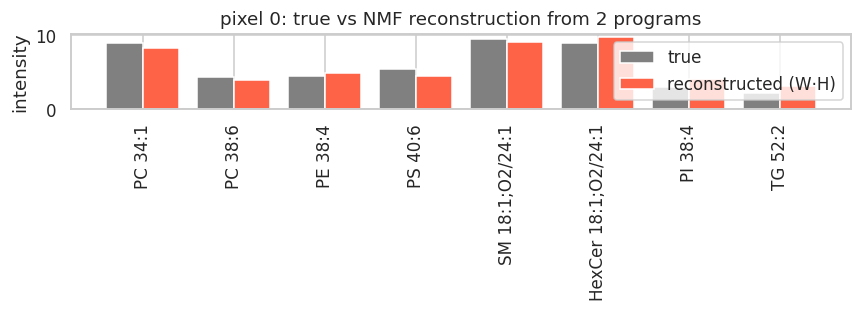

In [10]:
# reconstruct the pixel x lipid matrix from the two factors, then measure the error
V_hat = W @ H                                   # matrix product: (300x2) @ (2x8) -> (300x8)
rel_err = np.linalg.norm(X_lipids - V_hat) / np.linalg.norm(X_lipids)
print(f"relative reconstruction error with {k} programs: {rel_err*100:.1f}%")

# show one pixel's true vs reconstructed lipid profile
i = 0
fig, ax = plt.subplots(figsize=(8, 3))
width = 0.4
xpos = np.arange(len(lipids))
ax.bar(xpos - width/2, X_lipids[i], width, label="true", color="grey")
ax.bar(xpos + width/2, V_hat[i],    width, label="reconstructed (W·H)", color="tomato")
ax.set_xticks(xpos); ax.set_xticklabels(lipids, rotation=90)
ax.set_ylabel("intensity"); ax.set_title(f"pixel {i}: true vs NMF reconstruction from 2 programs")
ax.legend(); plt.tight_layout(); plt.show()

⚠️ **CHECKPOINT.** The reconstruction error is about ten percent and the true vs
reconstructed bars for one pixel nearly overlap: two non-negative programs already explain the bulk
of an 8-lipid table. Program 1 and program 2 cleanly map onto the two regions.

❓ **QUESTION.** PCA gave you axes with mixed signs; NMF gave you two recipes you could almost name
("the sphingolipid program", "the membrane-phospholipid program"). For writing a results paragraph
about *which lipids define a region*, which representation would you rather hand a biologist, and why?

---
## 3 · t-SNE and UMAP: a 2D picture you run on top of PCA / NMF

**The problem.** Even after PCA or NMF you have several dimensions, and screens are flat. You want a
single 2D scatter where similar pixels land near each other, so you can *see* the structure at a
glance.

**The picture.** t-SNE and UMAP are nonlinear "neighbourhood-preserving" maps. They look at who each
point's near neighbours are in the high-dimensional embedding and try to keep those same points close
together in 2D, letting faraway points fall wherever. The result is a picture where tight blobs are
genuinely similar groups.

**Run them on top of PCA / NMF, never on raw features.** We always feed t-SNE / UMAP the compressed
embedding (the PCA scores or NMF factors), not the hundreds of raw lipids. Three reasons: it is much
faster, the embedding has already denoised the data, and high-dimensional raw distances are unreliable
(everything drifts equidistant, the "curse of dimensionality"). This is the single sentence that
motivated the whole pipeline order: **compress first (PCA / NMF), then look (UMAP) and group (next
section).**

⚠️ **A warning you must internalise.** A t-SNE or UMAP plot is **for looking, not for measuring.**
The algorithm preserves local neighbourhoods, not global geometry. So:

- the **distance** between two clusters on the plot is **not** meaningful,
- the **size** of a cluster blob is **not** meaningful,
- **empty gaps** between blobs are **not** meaningful.

Use these plots to *see that groups exist* and to colour by metadata. Never use them to claim "group A
is twice as far from B as from C". For that you go back to the numbers.

**Where it appears in our pipeline.** From N4 onward we draw UMAPs of the NMF embedding to eyeball the
lipizone structure and to colour pixels by region, condition, or cluster. They are figures, not
measurements.

📺 **2-minute video.** StatQuest, *UMAP main ideas*: <https://www.youtube.com/watch?v=eN0wFzBA4Sc>.
For t-SNE, the StatQuest video index: <https://statquest.org/video_index.html>. A side-by-side of
PCA vs t-SNE vs UMAP: <https://biostatsquid.com/pca-umap-tsne-comparison/>.

One argument is worth a word: `perplexity=30`. Roughly, perplexity sets how big a local
neighbourhood t-SNE tries to preserve, how many near points each pixel is balanced against. It is a knob you will rarely touch; the default of 30 is fine for almost everything, and you only nudge it for very small datasets.

🔬 **TASK.** Run a t-SNE on the **NMF factors** (W) from the previous section and colour by
region. With only two NMF dimensions this is a gentle demo, but the recipe, *embed first, then 2D*,
is exactly what the real notebooks do.

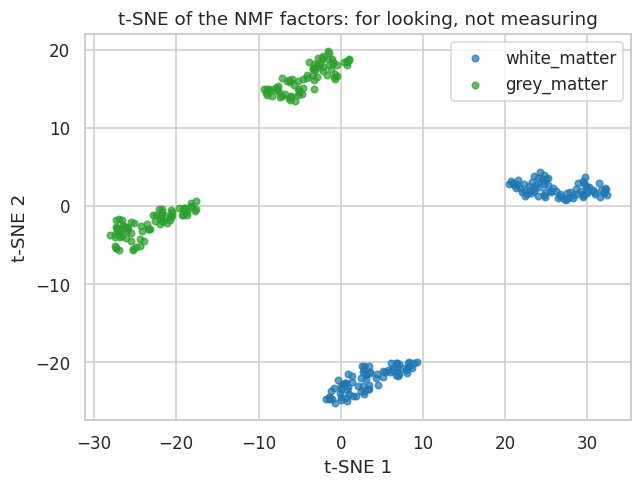

In [11]:
from sklearn.manifold import TSNE

# feed t-SNE the NMF factors W, NOT the raw lipids -> the "compress first, then look" rule
tsne = TSNE(n_components=2, perplexity=30, init="pca",
            random_state=RNG_SEED, learning_rate="auto")
emb2d = tsne.fit_transform(W)

fig, ax = plt.subplots(figsize=(6, 4.6))
for reg, colour in [("white_matter", "tab:blue"), ("grey_matter", "tab:green")]:
    m = df["region"].values == reg
    ax.scatter(emb2d[m, 0], emb2d[m, 1], s=18, alpha=0.7, label=reg, color=colour)
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
ax.set_title("t-SNE of the NMF factors: for looking, not measuring")
ax.legend(); plt.tight_layout(); plt.show()

⚠️ **CHECKPOINT.** Two clear blobs, one per region. Notice that the *axis numbers* are
arbitrary and the gap between blobs carries no quantitative meaning, that is the warning in action.

❓ **QUESTION.** If a reviewer asked "how different are these two regions, in numbers?", would you
point at this t-SNE plot or go back to the Wilcoxon test we build later? Why?

---
## 4 · Harmony: make batches overlap without erasing biology

**The problem.** We have two tissue sections, control and pregnant, run as two **batches**. Beyond any
real biology, each batch carries a technical offset (different day, slightly different instrument
state). In the embedding, pixels can cluster by *which section they came from* instead of by biology.
We want pixels of the same biological type to mix across sections, while keeping the real
control-vs-pregnant differences intact.

**The picture.** Picture the NMF cloud with each pixel coloured by its batch. Batch effects show up as
the same biological group split into two side-by-side sub-clouds, one per section. Harmony repeatedly
does two things: (1) **softly cluster** all pixels together, ignoring batch, then (2) within each soft
cluster, **nudge each batch's pixels toward the cluster's shared centre**, removing the part of the
offset that is purely "which section". Iterate, and groups that are biologically the same melt
together while genuinely different groups stay apart. Crucially Harmony **only edits the embedding
coordinates** (the NMF / PCA factors). It never touches the raw lipid intensities.

🚨 **COURSE-CRITICAL DISTINCTION. Read this twice.**
Harmony's batch-corrected embedding is used **only for clustering and label transfer** (the next two
sections). It is **never** used for the differential test. When we ask "is this lipid different between
control and pregnant?" (Wilcoxon, section 7) we run that test on the **uMAIA-normalized,
NON-Harmonized** intensities. Why: Harmony's whole job is to *make the two conditions overlap*, so
testing for a condition difference on Harmonized values would be testing on data we deliberately
squashed the condition difference out of. You would erase the very effect you are trying to measure.

> **Harmony → cluster and transfer labels.  uMAIA-normalized non-Harmonized data → differential test.**

Keep these two tracks separate in your head; mixing them is the single easiest way to get a wrong
result in this pipeline.

**Where it appears in our pipeline.** N4. N5: after NMF we run Harmony across the two sections to get a
shared space for Leiden clustering and for transferring lipizone labels from control onto pregnant.

📺 No good 2-minute Harmony video exists. The clearest reads are the single-cell best-practices
integration chapter <https://www.sc-best-practices.org/cellular_structure/integration.html>, the
scanpy wrapper docs
<https://scanpy.readthedocs.io/en/stable/generated/scanpy.external.pp.harmony_integrate.html>, and the
Broad quickstart <https://portals.broadinstitute.org/harmony/articles/quickstart.html>.

🔬 **TASK.** See the batch effect first. Plot the NMF factors coloured by **condition** (not
region). Because we injected a uniform shift into pregnant pixels, the two conditions sit offset from
each other even within the same region.

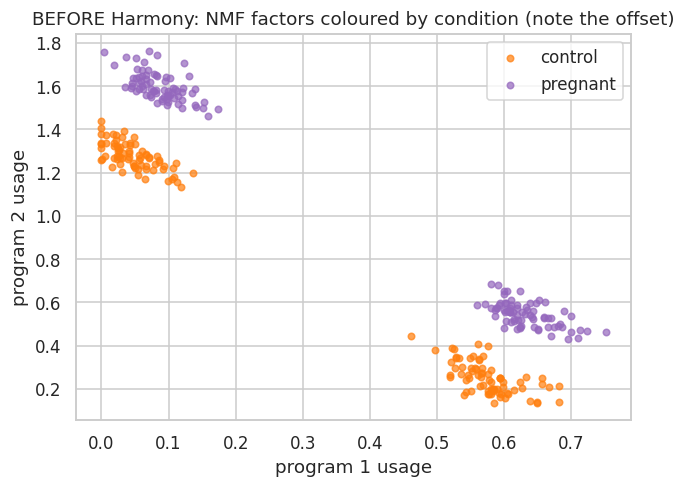

In [12]:
# colour the SAME NMF embedding by condition to expose the batch offset
fig, ax = plt.subplots(figsize=(6, 4.6))
for cond, colour in [("control", "tab:orange"), ("pregnant", "tab:purple")]:
    m = df["condition"].values == cond
    ax.scatter(W[m, 0], W[m, 1], s=18, alpha=0.7, label=cond, color=colour)
ax.set_xlabel("program 1 usage"); ax.set_ylabel("program 2 usage")
ax.set_title("BEFORE Harmony: NMF factors coloured by condition (note the offset)")
ax.legend(); plt.tight_layout(); plt.show()

Now run Harmony with `condition` as the batch variable and look again. The two conditions
should overlap far more, the technical offset is absorbed, while the two regions stay distinct.

In [13]:
import harmonypy

# Harmony needs the embedding (the NMF factors) and a metadata table naming the batch column
meta = df[["condition", "region"]].copy()
ho = harmonypy.run_harmony(W, meta, vars_use=["condition"], random_state=RNG_SEED)
# orient the corrected embedding to (pixels, programs) whatever harmonypy returned
W_harm = np.asarray(ho.Z_corr)
if W_harm.shape[0] != W.shape[0]:
    W_harm = W_harm.T
print("Harmonized embedding shape:", W_harm.shape)

2026-06-21 19:12:44,462 - harmonypy - INFO - Running Harmony (PyTorch on cuda)


2026-06-21 19:12:44,462 - harmonypy - INFO -   Parameters:


2026-06-21 19:12:44,463 - harmonypy - INFO -     max_iter_harmony: 10


2026-06-21 19:12:44,463 - harmonypy - INFO -     max_iter_kmeans: 20


2026-06-21 19:12:44,463 - harmonypy - INFO -     epsilon_cluster: 1e-05


...

2026-06-21 19:12:44,648 - harmonypy - INFO - Iteration 1 of 10


2026-06-21 19:12:44,714 - harmonypy - INFO - Iteration 2 of 10


2026-06-21 19:12:44,725 - harmonypy - INFO - Iteration 3 of 10


2026-06-21 19:12:44,737 - harmonypy - INFO - Converged after 3 iterations


Harmonized embedding shape: (300, 2)


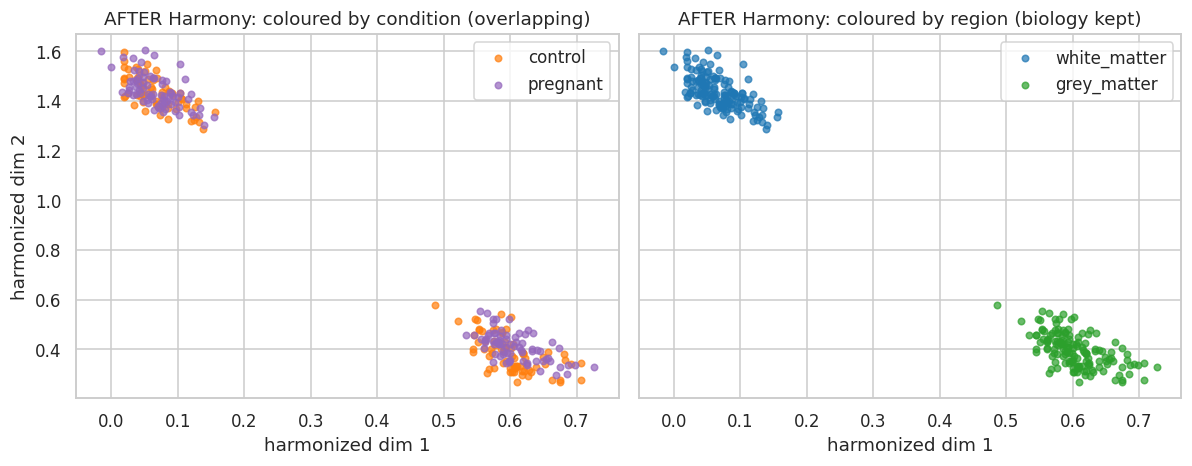

In [14]:
# AFTER Harmony: the same plot, coloured by condition -> the conditions now overlap
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharex=True, sharey=True)
for cond, colour in [("control", "tab:orange"), ("pregnant", "tab:purple")]:
    m = df["condition"].values == cond
    axes[0].scatter(W_harm[m, 0], W_harm[m, 1], s=18, alpha=0.7, label=cond, color=colour)
axes[0].set_title("AFTER Harmony: coloured by condition (overlapping)")
axes[0].set_xlabel("harmonized dim 1"); axes[0].set_ylabel("harmonized dim 2"); axes[0].legend()

for reg, colour in [("white_matter", "tab:blue"), ("grey_matter", "tab:green")]:
    m = df["region"].values == reg
    axes[1].scatter(W_harm[m, 0], W_harm[m, 1], s=18, alpha=0.7, label=reg, color=colour)
axes[1].set_title("AFTER Harmony: coloured by region (biology kept)")
axes[1].set_xlabel("harmonized dim 1"); axes[1].legend()
plt.tight_layout(); plt.show()

⚠️ **CHECKPOINT.** Left panel: control and pregnant now sit on top of each other, the batch
offset is gone. Right panel: the two regions are still clearly separated, the biology survived. That
is exactly what "make batches overlap without erasing biology" means, and exactly why we cluster on
this space but test on the non-Harmonized data.

---
## 5 · k-nearest-neighbour graph + Leiden: group pixels by who their neighbours are

**The problem.** We have a Harmonized embedding but no group labels. We want to carve the pixels into
discrete groups (here, lipid-defined regions, "lipizones") without telling the algorithm how many
groups to expect.

**The picture, part 1: the kNN graph.** For each pixel, find its **k nearest neighbours** in the
embedding and draw a line to each. Do this for all pixels and you get a network: pixels that are close
in lipid space are linked, pixels far apart are not. The graph is just "who is similar to whom",
written as connections.

**The picture, part 2: Leiden.** Leiden looks at this graph and finds **communities**: groups of
pixels that are densely wired to each other and sparsely wired to the rest, exactly how you would spot
friend-groups in a social network. Each community becomes a cluster. Two knobs matter:

- **`n_neighbors`** (the k): how local the graph is. Small k = fine, fragmented structure; large k =
  smoother, broader structure.
- **`resolution`**: how eagerly Leiden splits. Higher resolution = more, smaller clusters; lower =
  fewer, bigger ones.

**Where it appears in our pipeline.** N5 builds the neighbour graph on the Harmonized NMF embedding
(`sc.pp.neighbors`) and runs `sc.tl.leiden` to define lipizones. We then characterise each lipizone by
its marker lipids.

📺 **Read.** Single-cell best-practices clustering chapter
<https://www.sc-best-practices.org/cellular_structure/clustering.html> and the scanpy clustering
tutorial <https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering.html>.

🔬 **TASK.** Build a kNN graph on the Harmonized embedding and run Leiden. We do it through
**scanpy** here, the exact functions the real notebooks call, so this demo doubles as a preview. We
wrap our toy arrays in an AnnData object first (the "smart container" from notebook 01).

In [15]:
import scanpy as sc
import anndata as ad

# wrap the toy data as AnnData: X = lipid intensities, obs = pixel metadata
adata = ad.AnnData(X=X_lipids.astype("float32"),
                   obs=df[["region", "condition"]].reset_index(drop=True),
                   var=pd.DataFrame(index=lipids))
# store the Harmonized embedding where scanpy looks for a precomputed representation
adata.obsm["X_harmony"] = W_harm.astype("float32")

# 1) kNN graph on the Harmonized embedding; 2) Leiden communities on that graph
sc.pp.neighbors(adata, n_neighbors=15, use_rep="X_harmony", random_state=RNG_SEED)
sc.tl.leiden(adata, resolution=0.05, random_state=RNG_SEED, flavor="igraph", n_iterations=2)

print("Leiden clusters found:", sorted(adata.obs["leiden"].unique().tolist()))
print(adata.obs["leiden"].value_counts())

/home/fusar/mambaforge/lib/python3.12/functools.py:907: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


Leiden clusters found: ['0', '1']
leiden
0    150
1    150
Name: count, dtype: int64


Check the clustering against the truth. We never gave Leiden the region labels, so a clean
match means the graph + community structure recovered the biology on its own.

region  grey_matter  white_matter
leiden                           
0                 0           150
1               150             0


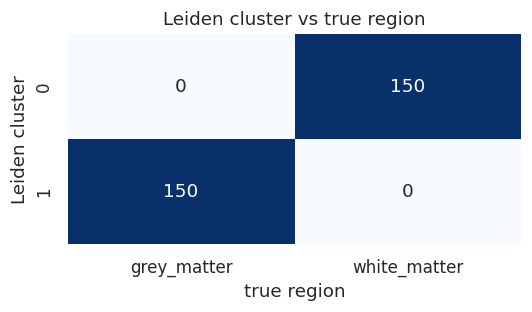

In [16]:
# cross-tabulate Leiden clusters against the true region -> should be near block-diagonal
ct = pd.crosstab(adata.obs["leiden"], adata.obs["region"])
print(ct)

fig, ax = plt.subplots(figsize=(5, 3))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_title("Leiden cluster vs true region")
ax.set_xlabel("true region"); ax.set_ylabel("Leiden cluster")
plt.tight_layout(); plt.show()

⚠️ **CHECKPOINT.** Two Leiden clusters, each lining up almost perfectly with one region: the
counts pile onto the diagonal. The neighbour graph plus community detection rediscovered our two
regions with zero supervision.

💡 **HINT.** Our two regions are so cleanly separated that we used a low `resolution=0.05` to get
exactly two clusters; push it higher and Leiden happily splits each blob further. Try
`resolution=0.3` and rerun to watch the count climb, this is exactly the dial you will tune on the
real data, where the right number of lipizones is a judgement call.

---
## 6 · kNN label transfer: copy labels from a reference onto new pixels

**The problem.** We will carefully annotate one section (say control) into named lipizones. We do
**not** want to re-cluster the other section from scratch and then puzzle out which new cluster matches
which old one. We want to *carry the existing labels over* to the new pixels in the shared space.

**The picture.** Same kNN idea as Leiden, used differently. For each **query** pixel (unlabelled), find
its nearest **reference** pixels (labelled) in the shared embedding, and take a **majority vote** of
their labels. The pixel inherits whatever its neighbours mostly are. A bonus: how *unanimous* the
neighbours are gives you a **confidence**, a pixel whose 15 neighbours are all "lipizone A" is a
confident call; a pixel split 8. 7 is a flag to inspect.

**Where it appears in our pipeline.** After clustering one section we transfer those lipizone labels
onto the other section through the Harmonized space, so both sections speak the same label vocabulary
and we can compare like with like. scanpy's `sc.tl.ingest` is the off-the-shelf version of this idea
(a kNN classifier for labels plus a UMAP for coordinates).

📺 **Read.** Single-cell best-practices annotation chapter
<https://www.sc-best-practices.org/cellular_structure/annotation.html> and the scanpy `tl.ingest` docs
<https://scanpy.readthedocs.io/en/stable/generated/scanpy.tl.ingest.html>.

🔬 **TASK.** Do the transfer by hand with scikit-learn's `KNeighborsClassifier` so you see there is no
magic: fit on a labelled reference, predict on a held-out query, then check accuracy against the truth.

In [17]:
from sklearn.neighbors import KNeighborsClassifier

# pretend the CONTROL pixels are the labelled reference and PREGNANT pixels are the unlabelled query
is_ref = (adata.obs["condition"] == "control").values
X_ref,   y_ref   = W_harm[is_ref],  adata.obs["region"].values[is_ref]    # reference: embedding + true region label
X_query, y_truth = W_harm[~is_ref], adata.obs["region"].values[~is_ref]   # query: embedding + (hidden) truth

# fit a k-nearest-neighbour vote on the reference, then transfer labels onto the query
knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(X_ref, y_ref)
y_pred = knn.predict(X_query)

# confidence = fraction of the 15 neighbours that voted for the winning label
proba = knn.predict_proba(X_query).max(axis=1)

acc = (y_pred == y_truth).mean()
print(f"transferred {len(y_pred)} labels; accuracy vs truth = {acc*100:.1f}%")
print(f"mean confidence of the calls = {proba.mean()*100:.1f}%")

transferred 150 labels; accuracy vs truth = 100.0%
mean confidence of the calls = 100.0%


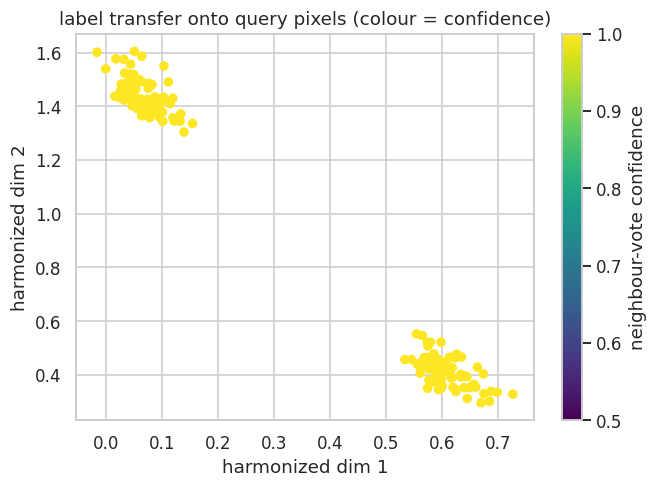

In [18]:
# show where the transfer is confident vs uncertain, and where it was wrong
fig, ax = plt.subplots(figsize=(6.2, 4.6))
sc_plot = ax.scatter(X_query[:, 0], X_query[:, 1], c=proba, cmap="viridis",
                     s=28, vmin=0.5, vmax=1.0)
wrong = y_pred != y_truth
ax.scatter(X_query[wrong, 0], X_query[wrong, 1], facecolors="none",
           edgecolors="red", s=90, linewidths=1.6, label="mislabelled")
ax.set_xlabel("harmonized dim 1"); ax.set_ylabel("harmonized dim 2")
ax.set_title("label transfer onto query pixels (colour = confidence)")
plt.colorbar(sc_plot, ax=ax, label="neighbour-vote confidence")
if wrong.any():
    ax.legend()
plt.tight_layout(); plt.show()

⚠️ **CHECKPOINT.** Our two regions are so cleanly separated that every call is unanimous: accuracy is 100% and mean confidence is 100%. So the confidence plot is uniformly bright and nothing is flagged, there are no dim points and no red mislabel rings to hunt for. On real data, where biology is messier, you would instead see a gradient, with the boundary pixels (where neighbours disagree) dimming and some picking up red rings. That low-confidence boundary is what you would manually review.

❓ **QUESTION.** Notice both Leiden (section 5) and label transfer use the *same* "look at nearest
neighbours" idea on the *same* Harmonized space. One groups pixels from scratch; the other copies
existing labels. Why does it make sense that both run on the Harmonized embedding rather than the raw
lipids?

---
## 7 · Wilcoxon rank-sum + Benjamini-Hochberg: is this lipid different, and how many findings are flukes?

This is **the course's differential test**, the moment we ask the actual biological question: *for
each lipid, does its abundance differ between control and pregnant?* The real differential notebook
unrolls exactly the two one-liners below, so treat this section as a code preview.

**First, what is a fold change?** A *fold change* is simply the ratio of the two group means, pregnant divided by control. If a lipid averages 8 in pregnant and 4 in control, its fold change is 8/4 = 2, a doubling. We then take **log2** of that ratio, and the reason is symmetry: a doubling (ratio 2) becomes log2(2) = **+1**, a halving (ratio 0.5) becomes log2(0.5) = **-1**, and no change (ratio 1) becomes log2(1) = **0**. So on a log2 fold change axis, up and down are mirror images around zero, and zero means "no difference". That is the number we put on the x-axis of the volcano plot.

**Part A: the Wilcoxon rank-sum test (a.k.a. Mann-Whitney U).**

*The problem.* Compare a lipid's values in control vs pregnant and decide whether the difference is
real or just noise, without assuming the data is nicely bell-shaped (lipid intensities often are not).

*The picture.* Forget the raw numbers; **rank** all values from both groups together, smallest to
largest. If the two groups were the same, high and low ranks would be shuffled evenly between them. If
one group's values systematically grab the higher ranks, the groups differ. The test only cares about
*ordering*, which makes it **nonparametric** (no normality assumption) and **robust to outliers** (one
huge value just becomes "the top rank", it cannot drag a mean around). We run it per lipid, control vs
pregnant.

**Part B: Benjamini-Hochberg false-discovery-rate control.**

*The problem.* We do not test one lipid; we test many lipids across many clusters, thousands of
comparisons. At a 5% threshold, **about 5% of pure-noise tests pass by chance**. Test 1000 flat lipids
and ~50 will clear the threshold while being flukes. We need to control how many of our reported hits
are false.

*The picture.* Bonferroni correction (divide the threshold by the number of tests) is brutally strict
and throws away real findings. **Benjamini-Hochberg** instead controls the **false discovery rate**:
the expected *fraction of your reported hits that are false*. It sorts the p-values smallest to
largest, compares the i-th smallest p-value to a sloped line `(i / m) · Q` (with `m` tests and target
FDR `Q`, e.g. 0.05), and keeps every test up to the largest one that still falls under the line.
Calling something significant at "BH-adjusted p < 0.05" means *you expect at most 5% of your calls to
be false*. That is far more useful, and standard in omics.

**Where it appears in our pipeline.** N6: per lipizone, per lipid, control vs pregnant, run Wilcoxon,
then BH-correct across all those tests, then read the volcano plot. **And remember section 4: this test
runs on the uMAIA-normalized, NON-Harmonized intensities.**

📺 **2-minute video.** StatQuest, *False Discovery Rates, FDR, clearly explained*:
<https://www.youtube.com/watch?v=K8LQSvtjcEo>. Concise notes on Wilcoxon + multiple testing (Cornell
qBio): <https://physiology.med.cornell.edu/people/banfelder/qbio/lecture_notes/1.6_multiple_hypotheses_and_non_parametric_tests.pdf>.

🔬 **TASK.** Run a Wilcoxon test **for every lipid**, control vs pregnant, with
`scipy.stats.mannwhitneyu`. Remember what we built: a uniform batch shift lifted *every* lipid in
pregnant, and on top of that `HexCer` got a *real* extra increase. So a naive per-lipid test on these
raw values will flag the batch shift too, which is precisely why the real pipeline tests on
batch-aware uMAIA-normalized data, not on data still carrying a raw offset. Here we test the raw toy
intensities to see the mechanics, and we will read the result with that caveat in mind.

In [19]:
# one Wilcoxon rank-sum test per lipid: control values vs pregnant values
ctrl = df["condition"].values == "control"
preg = df["condition"].values == "pregnant"

rows = []
for lip in lipids:
    a = df.loc[ctrl, lip].values
    b = df.loc[preg, lip].values
    # two-sided Mann-Whitney U: does the ordering differ between the two groups?
    U, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    log2fc = np.log2(b.mean() / a.mean())   # effect size: log2 fold change, pregnant vs control
    rows.append({"lipid": lip, "log2FC": log2fc, "p_value": p})

res = pd.DataFrame(rows)
res

,lipid,log2FC,p_value
0,PC 34:1,0.290166,8.366862e-11
1,PC 38:6,0.327966,3.345106e-12
2,PE 38:4,0.281224,1.658581e-10
3,PS 40:6,0.305402,8.222358e-12
4,SM 18:1;O2/24:1,0.263714,1.702452e-10
5,HexCer 18:1;O2/24:1,0.718693,1.435126e-14
6,PI 38:4,0.355612,6.230026e-13
7,TG 52:2,0.549966,4.088809e-35


Now the multiple-testing correction. We have 8 p-values; apply Benjamini-Hochberg with
`statsmodels` and compare raw vs adjusted.

In [20]:
# Benjamini-Hochberg: turn the 8 raw p-values into FDR-adjusted q-values
reject, q_values, _, _ = multipletests(res["p_value"].values, alpha=0.05, method="fdr_bh")
res["q_value"] = q_values
res["significant_BH"] = reject
res.sort_values("q_value")

,lipid,log2FC,p_value,q_value,significant_BH
7,TG 52:2,0.549966,4.088809e-35,3.271047e-34,True
5,HexCer 18:1;O2/24:1,0.718693,1.435126e-14,5.740505e-14,True
6,PI 38:4,0.355612,6.230026e-13,1.661340e-12,True
1,PC 38:6,0.327966,3.345106e-12,6.690213e-12,True
3,PS 40:6,0.305402,8.222358e-12,1.315577e-11,True
0,PC 34:1,0.290166,8.366862e-11,1.115582e-10,True
2,PE 38:4,0.281224,1.658581e-10,1.702452e-10,True
4,SM 18:1;O2/24:1,0.263714,1.702452e-10,1.702452e-10,True


A **volcano plot** is the standard way to read this: effect size (log2 fold change) on x,
statistical confidence on y. The y-axis is **-log10 of the adjusted p-value**, and here is why we negate-and-log it. A p-value is small when a result is convincing (0.001 is far more confident than 0.2), but small numbers are hard to read on a plot. Taking log10 spreads them out, and negating flips the order so that *small p-values become large positive y*. The upshot: the most confident hits sit at the **top**, and a less confident result sits low. Big *and* confident hits fly to the top corners.

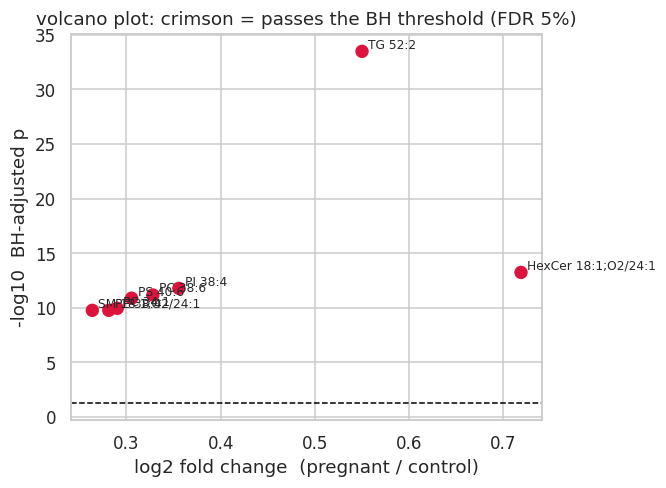

biggest effect: {'lipid': 'HexCer 18:1;O2/24:1', 'log2FC': 0.7186931867832459}


In [21]:
# volcano plot: x = effect size, y = confidence (-log10 adjusted p); colour = passed BH
res["neglog10q"] = -np.log10(res["q_value"].clip(lower=1e-300))

fig, ax = plt.subplots(figsize=(6.2, 4.6))
colours = np.where(res["significant_BH"], "crimson", "grey")
ax.scatter(res["log2FC"], res["neglog10q"], c=colours, s=60)
for _, r in res.iterrows():
    ax.annotate(r["lipid"], (r["log2FC"], r["neglog10q"]),
                fontsize=8, xytext=(4, 2), textcoords="offset points")
ax.axhline(-np.log10(0.05), ls="--", color="black", lw=1)
ax.set_xlabel("log2 fold change  (pregnant / control)")
ax.set_ylabel("-log10  BH-adjusted p")
ax.set_title("volcano plot: crimson = passes the BH threshold (FDR 5%)")
plt.tight_layout(); plt.show()

print("biggest effect:",
      res.sort_values('log2FC', ascending=False).iloc[0][['lipid', 'log2FC']].to_dict())

⚠️ **CHECKPOINT.** `HexCer 18:1;O2/24:1` shows the **largest** log2 fold change, it is the one
lipid we gave a real extra increase on top of the shared batch shift, so it stands out above the rest.
The dashed line marks the FDR-5% threshold.

❓ **QUESTION.** Several lipids pass the threshold here because our toy batch shift lifted *all* of
them in pregnant. On real data the uMAIA normalization (notebook N3) removes that kind of blanket
offset *before* this test, so what survives is closer to true biology. In your own words: why is it
dangerous to run a differential test on data that still carries a batch offset, and how does this tie
back to the Harmony rule in section 4?

---
## 8 · what is our data, physically? a MALDI-MSI and lipidomics primer

We built a toy table all the way through. Now the real thing it stands in for. No code here, just the
mental model you need before notebook N1 hands you actual spectra.

### MALDI mass spectrometry imaging, pixel by pixel

**MALDI** is matrix-assisted laser desorption/ionization. **MSI** is mass spectrometry imaging. Put
together, here is what physically happens to a brain section:

1. The tissue is coated with a light-absorbing **matrix** and mounted on a slide.
2. A **laser fires at one tiny spot** (a pixel). The matrix absorbs the energy and, in the blast,
   **desorbs and ionizes** the molecules sitting at that spot, flinging them into the gas phase as
   charged ions.
3. A **mass spectrometer** measures those ions and reports their **mass-to-charge ratio (m/z)**, plus
   how many of each there were (**intensity**). The output for one pixel is a **spectrum**: a list of
   `(m/z, intensity)` pairs, which is really just two aligned arrays, peak positions and peak heights.
4. The laser **steps to the next pixel** and repeats, raster-scanning the whole section.

Stack all those spectra on their `(x, y)` grid and you get a **hyperspectral image**: at every pixel,
an intensity for every m/z peak. Pick one m/z and you can draw its **spatial map** across the tissue,
that is a per-lipid image. This is label-free: no antibodies, no probes. One run sees hundreds of
molecules at once. The **pixel size sets the spatial resolution** (tens of microns, typically).

The catch, and the job of notebook N2: the instrument reports **m/z numbers, not lipid names**. Turning
a peak at some m/z into "this is `PC 34:1`" is **annotation**, matching measured masses (within a few
parts-per-million) to known lipid masses and their charged forms (adducts). Until annotated, a peak is
just a number.

So our toy table maps onto reality like this: **pixels = laser spots** (with `x, y`), **lipid columns =
annotated m/z peaks**, **intensities = peak heights**, **condition = which tissue section**. Everything
you did above is what you will do on real spectra.

### lipids, and the brain's favourites

**Lipids** are the cell's fats and oils: the molecules that build membranes, insulate axons, and store
energy. LIPID MAPS sorts them into 8 categories. For brain, two categories dominate our story:

- **Glycerophospholipids**, the membrane builders. A glycerol backbone, two fatty-acid tails, and a
  **head group** that names the class:
  - **PC**: phosphatidylcholine
  - **PE**: phosphatidylethanolamine
  - **PS**: phosphatidylserine
  - **PI**: phosphatidylinositol
- **Sphingolipids**, built on a sphingoid base, the **myelin** signature that insulates axons in white
  matter. Includes **sphingomyelin (SM)**, **ceramides (Cer)**, **hexosylceramides (HexCer**, e.g.
  galactosylceramide), **sulfatides**, and **gangliosides**.

This is why our toy white-matter region was loaded with `SM` and `HexCer`, and the grey-matter region
with `PC / PE / PS / PI`, that contrast is real brain biology in miniature.

### reading a lipid name: `PC 38:6`

Lipid shorthand packs the chemistry into a few characters:

> **`PC 38:6`** = a **PC** (phosphatidylcholine) head group, with **38** total carbons across its fatty
> tails and **6** carbon-carbon double bonds (degree of unsaturation).

So `PC 34:1` is a phosphatidylcholine with 34 carbons and 1 double bond. Sphingolipid names add the
backbone, e.g. `SM 18:1;O2/24:1`. You do **not** need to memorise structures. You need to read
**head group + chain-length:double-bonds** off a name, so a marker-lipid table is legible and you can
later build composite scores like a **myelination** score (summing sphingolipids) or a
**membrane-remodeling** score (summing log2 fold changes of glycerophospholipids).

📚 **Resources.**
- A beginner's guide to lipidomics (Portland Press, *The Biochemist*):
  <https://portlandpress.com/biochemist/article/44/1/20/230687/A-beginner-s-guide-to-lipidomics>
- LIPID MAPS CNS lipid classification: <https://www.lipidmaps.org/data/classification/lipid_cns.html>
- Spatial neurolipidomics, MALDI MSI of lipids in brain pathologies (Jha 2024):
  <https://pmc.ncbi.nlm.nih.gov/articles/PMC12013527/>
- The Lipid Brain Atlas dashboard (the course's own domain anchor): <https://lbae-v2.epfl.ch/>

---
## you made it: the pipeline, in one breath

You now hold every idea behind the buttons, in the order the course presses them:

1. **PCA**: rotate to the eigen-directions of variance, keep the few that matter. *Compress.*
2. **NMF**: same compression, but non-negative, so the factors are readable **lipid programs that add
   up**. This is the embedding we cluster on. *Compress, interpretably.*
3. **t-SNE / UMAP**: a 2D picture **on top of** the embedding, for looking, **not** measuring. *See.*
4. **Harmony**: make the two sections overlap without erasing biology, used **only** for clustering
   and label transfer, **never** for the differential test. *Align batches.*
5. **kNN graph + Leiden**: link each pixel to its neighbours, then find communities = lipizones.
   *Group.*
6. **kNN label transfer**: majority-vote labels from a reference onto new pixels, with a confidence.
   *Annotate.*
7. **Wilcoxon + Benjamini-Hochberg**: rank-based per-lipid test, FDR-corrected across all tests, run
   on uMAIA-normalized **non-Harmonized** data. *Test, honestly.*
8. **MALDI-MSI + lipids**: every pixel is a spectrum of m/z peaks; brain runs on
   glycerophospholipids and sphingolipids; names read as head group + chains:double-bonds. *The data
   itself.*

Two rules to carry into Thursday, because they are the easiest to get wrong:

- **t-SNE / UMAP distances are not quantitative.** Plots for looking; numbers for measuring.
- **Harmony for clustering and transfer; the differential test runs on uMAIA-normalized,
  non-Harmonized data.** Never test on data you batch-corrected.

⚠️ **FINAL CHECKPOINT.** Restart the kernel and run the whole notebook top to bottom (in VSCode:
"Restart" then "Run All"; in Jupyter: Kernel → Restart & Run All). Every cell should run green and
every figure should redraw. If it does, you are ready for the real project. See you in Bordeaux.

## References

- Fusar Bassini et al. *The lipidomic architecture of the mouse brain.* bioRxiv 2025.10.13.682018. The EUCLID method and the Lipid Brain Atlas: https://www.biorxiv.org/content/10.1101/2025.10.13.682018v1
- uMAIA: probabilistic normalization of mass-spectrometry imaging. *Nature Methods* (2025), s41592-025-02771-7.
- Allen Mouse Brain Common Coordinate Framework v3 (CCFv3), Allen Institute for Brain Science.
- Explore the atlas interactively: https://lbae-v2.epfl.ch/
